In [1]:
# # Análise Exploratória e Modelagem Preditiva da Frota Eletrificada em São Paulo
# *Autor: Felipe Ferreira Tavares*
#
# Este notebook consolida dados históricos obtidos via web scraping da Senatran sobre a
# evolução de veículos híbridos e elétricos no município de São Paulo entre 2024 e 2026.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# Força o Plotly a salvar uma cópia estática em PNG dentro do arquivo do notebook
import plotly.io as pio
pio.renderers.default = "png" # ou "svg"

In [3]:
ANOS = ["2024", "2025", "2026"]
MESES = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

mapa_meses_num = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Maro": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8, "Setembro": 9,
    "Outubro": 10, "Novembro": 11, "Dezembro": 12
}

combustiveis_interesse = [
    "ELETRICO", "ELETRICO/FONTE EXTERNA", "ELETRICO/FONTE INTERNA",
    "HIBRIDO", "HIBRIDO PLUG-IN", "GASOLINA/ELETRICO"
]

## 1. Consolidação e Engenharia de Dados (ETL Local)

In [4]:
arquivos_projeto = []
for ano in ANOS:
    for mes in MESES:
        arquivos_projeto.append({
            "nome_identificador": f"{mes}_{ano}",
            "nome_arquivo": f"D_Frota_por_UF_Municipio_COMBUSTIVEL_{mes}_{ano}.xlsx"
        })

pasta_data = Path.cwd().parent / "data"
lista_dfs = []

for item in arquivos_projeto:
    caminho_completo = pasta_data / item["nome_arquivo"]
    if caminho_completo.exists():
        df_temporario = pd.read_excel(caminho_completo)
        df_temporario["origem_dados"] = item["nome_identificador"]
        
        # Extraindo dimensões de tempo para facilitar análises avançadas
        df_temporario["Ano_Ref"] = int(item["nome_identificador"].split("_")[1])
        df_temporario["Mes_Nome"] = item["nome_identificador"].split("_")[0]
        df_temporario["Mes_Ref"] = df_temporario["Mes_Nome"].map(mapa_meses_num)
        
        lista_dfs.append(df_temporario)

if lista_dfs:
    df_final = pd.concat(lista_dfs, ignore_index=True)
    # Filtro focado estritamente no município de interesse e escopo elétrico/híbrido
    eletricos_sp = df_final[
        (df_final["Município"] == "SAO PAULO") & 
        (df_final["Combustível Veículo"].isin(combustiveis_interesse))
    ].copy()
    print(f"✓ Sucesso! {len(lista_dfs)} arquivos consolidados.")
else:
    print("⚠️ Nenhum arquivo carregado. Verifique os caminhos.")

✓ Sucesso! 30 arquivos consolidados.


2. Análise de Aceleração do Mercado (Métricas de Crescimento)

In [5]:
evolucao_geral = (
    eletricos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
).copy()

# Cálculo da variação percentual mês a mês (MoM)
evolucao_geral["Crescimento_MoM_%"] = (
    evolucao_geral["Qtd. Veículos"].pct_change() * 100
)

# CORREÇÃO: Usando pct_change com periods=12 para olhar 12 meses atrás (YoY)
evolucao_geral["Crescimento_YoY_%"] = (
    evolucao_geral["Qtd. Veículos"].pct_change(periods=12) * 100
)

print(
    "Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de"
    " Aceleração:"
)
print(
    evolucao_geral[
        [
            "Ano_Ref",
            "Mes_Nome",
            "Qtd. Veículos",
            "Crescimento_MoM_%",
            "Crescimento_YoY_%",
        ]
    ].tail(6)
)

Tabela de Evolução da Frota de Elétricos/Híbridos com Métricas de Aceleração:
    Ano_Ref   Mes_Nome  Qtd. Veículos  Crescimento_MoM_%  Crescimento_YoY_%
24     2026    Janeiro          84957           3.366590          53.393518
25     2026  Fevereiro          87723           3.255765          52.151591
26     2026      Março          92198           5.101285          53.384684
27     2026      Abril          97122           5.340680          56.426363
28     2026       Maio         101684           4.697185          57.899314
29     2026      Junho         107519           5.738366          61.260761


## 3. Visualização Interativa: Compartimentação por Tipo de Combustível

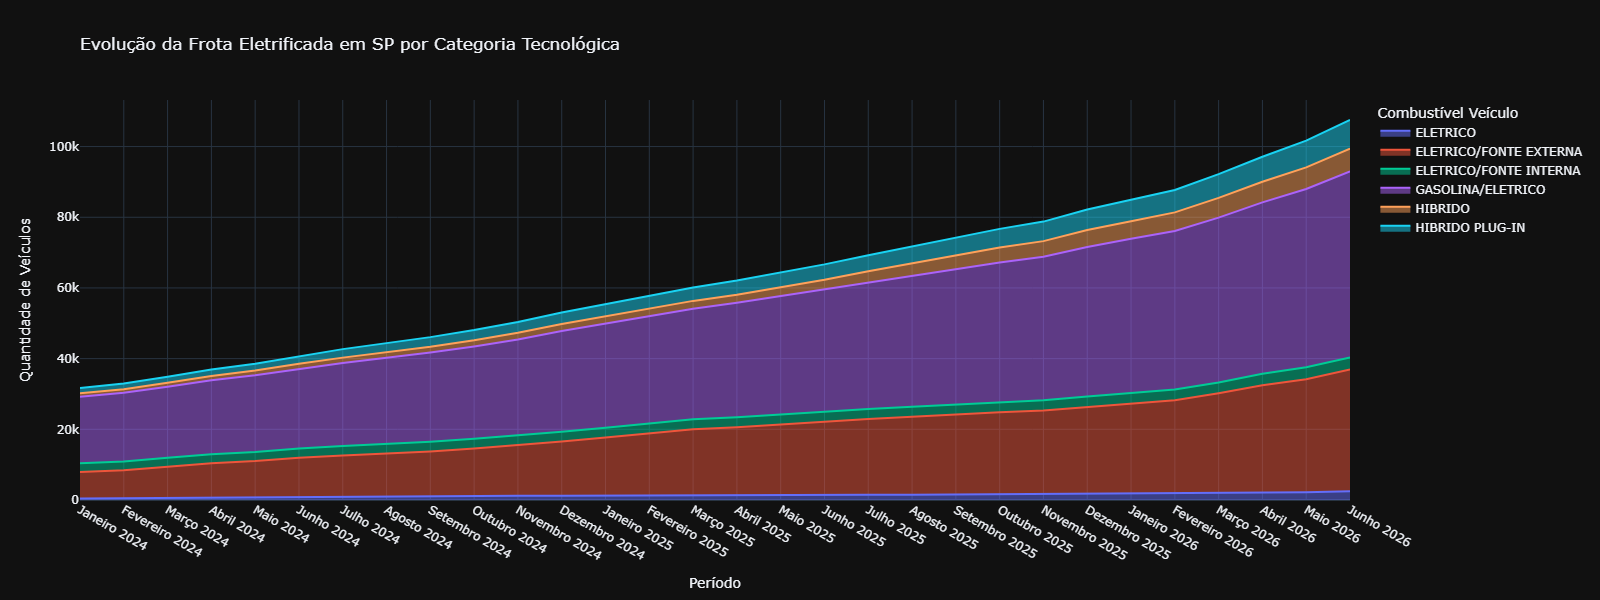

In [6]:
# Agrupamento para analisar a transição energética por categoria tecnológica
evolucao_combustivel = (
    eletricos_sp.groupby(["Ano_Ref", "Mes_Ref", "Mes_Nome", "Combustível Veículo"])["Qtd. Veículos"]
    .sum()
    .reset_index()
    .sort_values(["Ano_Ref", "Mes_Ref"])
)
evolucao_combustivel["Data"] = evolucao_combustivel["Mes_Nome"] + " " + evolucao_combustivel["Ano_Ref"].astype(str)

# Gráfico de Área Empilhada com Plotly para portfólio dinâmico
fig_comb = px.area(
    evolucao_combustivel, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Combustível Veículo",
    title="Evolução da Frota Eletrificada em SP por Categoria Tecnológica",
    labels={"Qtd. Veículos": "Quantidade de Veículos", "Data": "Período"},
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)
fig_comb.update_layout(xaxis={"categoryorder": "trace"})
fig_comb.show()

## 4. Modelo Preditivo (Forecasting até Dezembro de 2027)

In [7]:
# Preparando os dados para a regressão (Tempo vira um índice numérico incremental 1, 2, 3...)
evolucao_geral["Timeline_Index"] = range(1, len(evolucao_geral) + 1)

X = evolucao_geral[["Timeline_Index"]].values
y = evolucao_geral["Qtd. Veículos"].values

# Treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Projetando os próximos meses até Dezembro de 2027
ultimo_index = evolucao_geral["Timeline_Index"].max()
# Assumindo que o último dado coletado foi Junho de 2026 (Index 30), criamos mais 18 meses
meses_projeção = 18
futuro_index = np.arange(ultimo_index + 1, ultimo_index + 1 + meses_projeção).reshape(-1, 1)
predicoes_futuras = modelo.predict(futuro_index)

# Criando dataframe com as projeções
datas_futuras = [
    "Jul 2026", "Ago 2026", "Set 2026", "Out 2026", "Nov 2026", "Dez 2026",
    "Jan 2027", "Fev 2027", "Mar 2027", "Abr 2027", "Mai 2027", "Jun 2027",
    "Jul 2027", "Ago 2027", "Set 2027", "Out 2027", "Nov 2027", "Dez 2027"
]
df_projeção = pd.DataFrame({
    "Data": datas_futuras,
    "Qtd. Veículos": predicoes_futuras,
    "Tipo": "Projeção (Modelo Linear)"
})

df_real = pd.DataFrame({
    "Data": evolucao_geral["Mes_Nome"].str[:3] + " " + evolucao_geral["Ano_Ref"].astype(str),
    "Qtd. Veículos": y,
    "Tipo": "Dado Histórico (Senatran)"
})

df_fused = pd.concat([df_real, df_projeção], ignore_index=True)

## 5. Visualização do Modelo de Previsão de Demanda

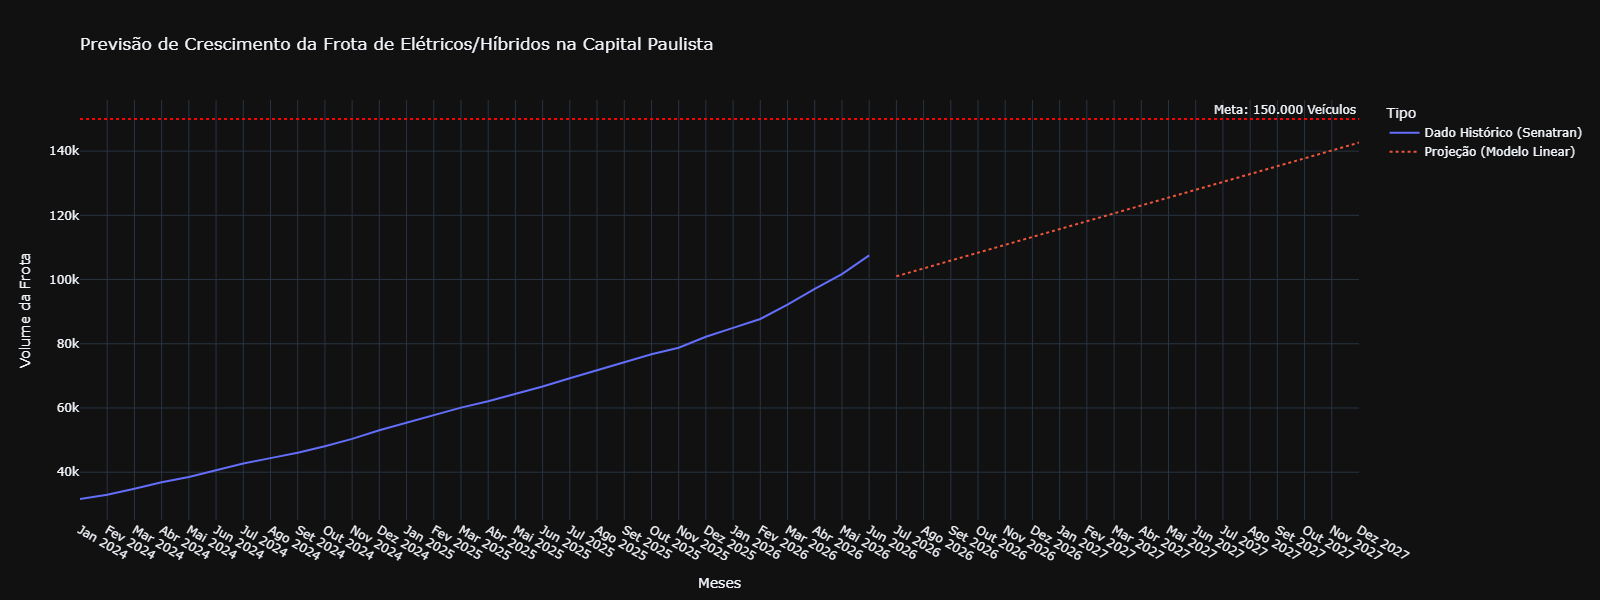

In [8]:
fig_pred = px.line(
    df_fused, 
    x="Data", 
    y="Qtd. Veículos", 
    color="Tipo",
    title="Previsão de Crescimento da Frota de Elétricos/Híbridos na Capital Paulista",
    labels={"Qtd. Veículos": "Volume da Frota", "Data": "Meses"},
    line_dash="Tipo",
    template="plotly_dark",
    width=1600,  # <-- ADICIONE ESTA LINHA
    height=600   # <-- ADICIONE ESTA LINHA
)

# Destacando o marco onde a frota ultrapassará 150 mil veículos
fig_pred.add_hline(y=150000, line_dash="dot", line_color="red", annotation_text="Meta: 150.000 Veículos")
fig_pred.show()

## 🏁 Conclusão da Análise Exploratória & Próximos Passos

### 📊 Principais Descobertas (Insights de Negócio)
1. **Crescimento Exponencial:** A frota de veículos elétricos e híbridos na cidade de São Paulo triplicou no intervalo analisado, saltando de **~31k (Jan/2024)** para **~107k (Jun/2026)**. Isso mostra que a adoção local está acontecendo de forma extremamente agressiva.
2. **Velocidade de Mercado:** Os cálculos de variação **YoY (Ano contra Ano)** indicam que o mercado não está apenas crescendo, mas acelerando o ritmo de novas aquisições a cada ano.
3. **Padrão de Transição:** Os veículos híbridos ainda representam o volume principal por conta da flexibilidade de abastecimento, mas a inclinação da curva dos elétricos puros (BEV) vem ganhando força à medida que infraestruturas privadas (prédios e shoppings) se expandem.

### 🔮 O Impacto do Modelo Preditivo
* O modelo de **Forecasting** sinaliza que o município de São Paulo romperá a barreira histórica de **150.000 veículos eletrificados circulando em 2027**.
* **Impacto Real:** Esse número acende um alerta para o ecossistema de mobilidade urbana (concessionárias de energia e redes de eletropostos). A velocidade de instalação de carregadores rápidos de rua precisará acelerar para evitar o estrangulamento e filas nos pontos de recarga públicos.

---

### 🚀 Próximos Passos para o Projeto (`02_modeling.ipynb`)
Para evoluir esta análise para um modelo de Machine Learning ainda mais robusto para o portfólio, os próximos passos sugeridos são:
* [ ] **Testar Modelos Não-Lineares:** Avaliar regressões polinomiais ou modelos específicos de séries temporais (como ARIMA ou Prophet) para capturar possíveis sazonalidades de fim de ano nas vendas.
* [ ] **Cruzamento de Dados Externos:** Adicionar variáveis explicativas externas (como histórico de preços de combustíveis fósseis ou volume de incentivos fiscais liberados na capital) para enriquecer os recursos (*feature engineering*) do modelo.